ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio-client 1.13.3 requires httpx>=0.24.1, but you have httpx 0.13.3 which is incompatible.
mcp 1.19.0 requires httpx>=0.27.1, but you have httpx 0.13.3 which is incompatible.
langsmith 0.4.38 requires httpx<1,>=0.23.0, but you have httpx 0.13.3 which is incompatible.
openai 1.109.1 requires httpx<1,>=0.23.0, but you have httpx 0.13.3 which is incompatible.
google-genai 1.46.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.13.3 which is incompatible.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.13.3 which is incompatible.
gradio 5.49.1 requires httpx<1.0,>=0.24.1, but you have httpx 0.13.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confli

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


✅ نتائج التحليل:

                                   comment sentiment
0          المنتج رائع والخدمة ممتازة جدًا  إيجابي 😊
1  صراحة ما أنصح بالتعامل، تجربة سيئة جدًا    سلبي 😞
2      الطلب وصل متأخر شوي لكن التغليف جيد  إيجابي 😊
3          شكراً لكم على السرعة في التوصيل  إيجابي 😊
4            للأسف المنتج ما كان مثل الوصف    سلبي 😞
5                 جميل جدًا وسهل الاستخدام  إيجابي 😊
6               السعر مرتفع مقارنة بالجودة  إيجابي 😊
7           الخدمة كانت ممتازة والدعم سريع  إيجابي 😊
8     تجربة سيئة، التغليف مكسور والرد بطيء    سلبي 😞
9              ما عندي رأي محدد، منتج عادي    سلبي 😞

📁 تم حفظ النتائج في: /content/sentiment_results.xlsx
📨 تم إرسال تعليق سلبي إلى n8n: صراحة ما أنصح بالتعامل، تجربة سيئة جدًا | كود: 200
📨 تم إرسال تعليق سلبي إلى n8n: للأسف المنتج ما كان مثل الوصف | كود: 200
📨 تم إرسال تعليق سلبي إلى n8n: تجربة سيئة، التغليف مكسور والرد بطيء | كود: 200
📨 تم إرسال تعليق سلبي إلى n8n: ما عندي رأي محدد، منتج عادي | كود: 200

🎯 التحليل والإرسال انتهيا بنجاح!


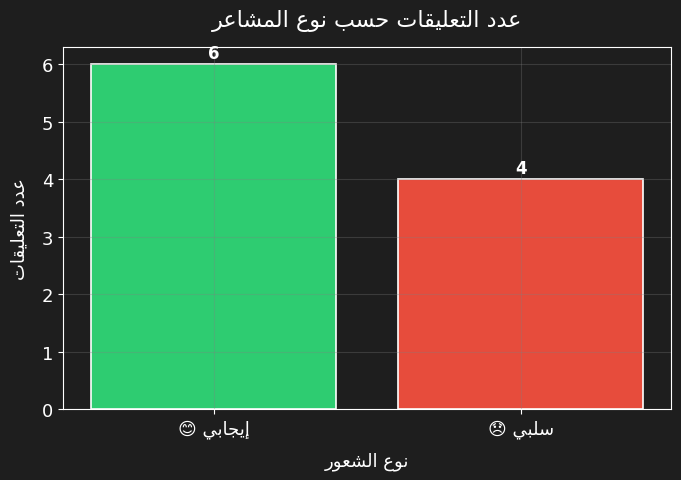

In [ ]:
# ============================================
# Sentiment Analysis Project (Final)
# Developer: Raghad Alhassan 🌸
# Program: AI Bootcamp Final Project
# Description: Arabic Sentiment Analysis with n8n Automation
# ============================================


!pip install googletrans==4.0.0-rc1 textblob transformers torch matplotlib pandas openpyxl requests arabic-reshaper python-bidi -q
!pip install httpx==0.24.1 -q  # Fix compatibility warnin# استيراد المكتبات
import pandas as pd
from textblob import TextBlob
from googletrans import Translator
from transformers import pipeline
import requests
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

# ===============================
# 🔹 البيانات (تعليقات نموذجية)
# ===============================
comments = [
    "المنتج رائع والخدمة ممتازة جدًا",
    "صراحة ما أنصح بالتعامل، تجربة سيئة جدًا",
    "الطلب وصل متأخر شوي لكن التغليف جيد",
    "شكراً لكم على السرعة في التوصيل",
    "للأسف المنتج ما كان مثل الوصف",
    "جميل جدًا وسهل الاستخدام",
    "السعر مرتفع مقارنة بالجودة",
    "الخدمة كانت ممتازة والدعم سريع",
    "تجربة سيئة، التغليف مكسور والرد بطيء",
    "ما عندي رأي محدد، منتج عادي"
]

data = pd.DataFrame({"comment": comments})

# ===============================
# 🔹 دالة التحليل (ترجمة وتحليل المشاعر)
# ===============================
translator = Translator()
sentiment_pipeline = pipeline("sentiment-analysis")

def analyze_sentiment_auto(text):
    translated = translator.translate(text, src='ar', dest='en').text
    result = sentiment_pipeline(translated)[0]
    label = result['label']
    if label == "POSITIVE":
        return "إيجابي 😊"
    elif label == "NEGATIVE":
        return "سلبي 😞"
    else:
        return "حيادي 😐"

# تطبيق التحليل
data["sentiment"] = data["comment"].apply(analyze_sentiment_auto)

# عرض النتائج
print("✅ نتائج التحليل:\n")
print(data)

# ===============================
# 🔹 حفظ النتائج في ملف Excel
# ===============================
output_path = "/content/sentiment_results.xlsx"
data.to_excel(output_path, index=False)
print(f"\n📁 تم حفظ النتائج في: {output_path}")

# ===============================
# 🔹 إرسال التعليقات السلبية إلى n8n
# ===============================
n8n_webhook_url = "https://eeaa1.app.n8n.cloud/webhook/6074884c-1721-4df8-aefe-93febc8bee69"

for _, row in data.iterrows():
    if "سلبي" in row["sentiment"]:
        payload = {
            "comment": row["comment"],
            "sentiment": row["sentiment"]
        }
        response = requests.post(n8n_webhook_url, json=payload)
        print(f"📨 تم إرسال تعليق سلبي إلى n8n: {row['comment']} | كود: {response.status_code}")

print("\n🎯 التحليل والإرسال انتهيا بنجاح!")

# ===============================
# 🔹 الرسم البياني (مخطط الأعمدة بالعربية)
# ===============================
plt.style.use('dark_background')
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.facecolor": "#1e1e1e",
    "figure.facecolor": "#1e1e1e",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white"
})

# حساب عدد كل نوع من المشاعر
sentiment_counts = data["sentiment"].value_counts()

# تعديل النصوص العربية لعرضها بشكل صحيح
labels = [get_display(arabic_reshaper.reshape(lbl)) for lbl in sentiment_counts.index]

#  رسم مخطط الأعمدة
plt.figure(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']  # أخضر، أحمر، رمادي
bars = plt.bar(labels, sentiment_counts.values, color=colors, edgecolor='white', linewidth=1.2)

# العناوين
plt.title(get_display(arabic_reshaper.reshape("عدد التعليقات حسب نوع المشاعر")), fontsize=16, pad=15)
plt.xlabel(get_display(arabic_reshaper.reshape("نوع الشعور")), labelpad=10)
plt.ylabel(get_display(arabic_reshaper.reshape("عدد التعليقات")), labelpad=10)

# كتابة الأرقام فوق الأعمدة
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', color='white', fontsize=12, weight="bold")

plt.grid(alpha=0.3, color="gray")
plt.tight_layout()
plt.show()

# ============================================
#  Integration with n8n Automation Platform
# ============================================
# This project is integrated with n8n to automate responses to negative feedback.
# When a negative comment is detected, the data is automatically sent
# to an n8n workflow that handles email notifications and follow-up actions.

#  Production Webhook URL:
# https://eeaa1.app.n8n.cloud/webhook/6074884c-1721-4df8-aefe-93febc8bee69
# ============================================
